In [1]:
import sys, glob, os, yaml, sparse, tracemalloc, vcf, subprocess, collections
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import itertools, difflib

import warnings
warnings.filterwarnings("ignore")

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from model_utils import *
from data_utils import *
from dataloader import MtbGeneDataset
import Bio.SeqUtils
from Bio import Seq, SeqIO

2023-04-25 13:16:17.193232: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-25 13:16:17.613653: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-04-25 13:16:17.613680: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-04-25 13:16:20.632790: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

In [2]:
# lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.tsv", sep="\t", header=None)

# # cleaning steps for readability
# lineages.columns = ["Isolate", "Coll2014", "Freschi2020", "Lipworth2019", "Shitikov2017", "Stucki2016"]
# lineages["Coll2014"] = [val.replace("lineage", "") for val in lineages["Coll2014"].values]
# lineages["Isolate"] = [val.split(".")[0] for val in lineages["Isolate"].values]
# lineages["Lineage"] = [val[0] if val[0].isnumeric() else val for val in lineages["Coll2014"].values]

lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineages.shape

(11759, 7)

# Get Lineages for the Validation Data

In [3]:
# df_mxf_og = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_with_paths.csv")
# df_mxf_og = df_mxf_og.query("DB_OF_ORIGIN=='CRyPTIC'").merge(lineages[["ROLLINGDB_ID", "Coll2014", "Lineage"]], on="ROLLINGDB_ID")

# df_rif_og = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_with_paths.csv")
# df_rif_og = df_rif_og.query("DB_OF_ORIGIN=='CRyPTIC'").merge(lineages[["ROLLINGDB_ID", "Coll2014", "Lineage"]], on="ROLLINGDB_ID")

df_rif_train = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")
df_mxf_train = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")

df_rif_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/validation_data_for_model.csv")
df_mxf_val = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/validation_data_for_model.csv")

print(df_rif_train.shape, df_rif_val.shape)
print(df_mxf_train.shape, df_mxf_val.shape)

(9137, 19) (1406, 17)
(7269, 19) (1300, 17)


# MIC Distributions

In [4]:
def plot_MIC_dist(drug, cc, saveName=None):
    
    df_train = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    df_val = pd.read_csv(os.path.join(data_path, drug, "validation_data_for_model.csv"))
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_train[f"{drug}_midpoint"], ax=ax[0], log_scale=2)
    sns.histplot(df_val[f"{drug}_midpoint"], ax=ax[1], log_scale=2)
    
    for axis in ax:
        axis.axvline(cc, color="black", linestyle="dashed", label=f"CC = {cc} µg/mL")
        #axis.set_xticks(ticks=axis.get_xticks(), labels=np.round(2**axis.get_xticks(), 2))
        axis.set_xlabel("MIC (µg/mL)")
    
    ax[0].set_title(f"Log2-Transformed {len(df_train)} Training/Testing MICs")
    ax[1].set_title(f"Log2-Transformed {len(df_val)} Validation MICs")
    
    plt.legend()
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()

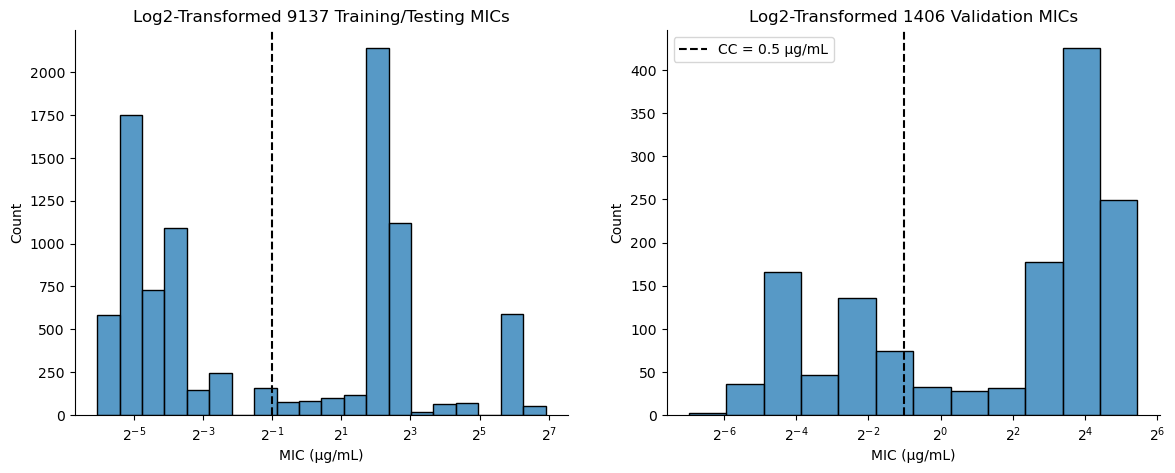

In [5]:
plot_MIC_dist("RIF", 0.5, saveName="Rifampicin/train_val_MICs.png")

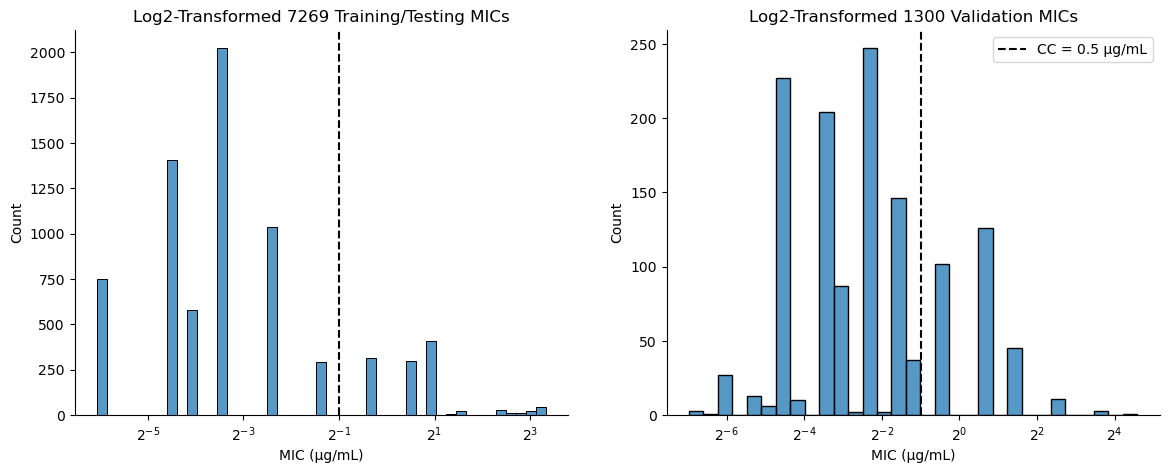

In [6]:
plot_MIC_dist("MXF", 0.5, saveName="Moxifloxacin/train_val_MICs.png")

# Training and Validation Set MIC Distributions (+ External Validation Sets)

In [7]:
def compare_distributions(drug, drug_full, label_xpos, saveName=None):
    
    df_train = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    df_val = pd.read_csv(os.path.join(data_path, drug, "validation_data_for_model.csv"))
    
    df_combined = pd.concat([df_train[["ROLLINGDB_ID", f"{drug}_midpoint", "category"]], 
                             df_val[["ROLLINGDB_ID", f"{drug}_midpoint"]]
                            ], axis=0)

    df_combined["Dataset"] = df_combined["category"].map({"original_train_set": "Train", "original_test_set": "Test"})
    df_combined["Dataset"] = df_combined["Dataset"].fillna("Validation")
    del df_combined["category"]
    
    fig, ax = plt.subplots()
    
    ax.axvline(0.5, color="black", linestyle="dashed", linewidth=1)
    
    sns.ecdfplot(data=df_combined,
                 x=f"{drug}_midpoint",
                 hue="Dataset",
                 log_scale=2,
                 ax=ax
                )
    
    plt.xlabel("MIC (µg/mL)")
    plt.title(f"{drug_full} MICs of Datasets\n")
    
    plt.text(label_xpos, 0.97, "CC = 0.5 µg/mL")
    sns.move_legend(ax, loc="lower right")
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()
        
    pval = st.ks_2samp(np.log2(df_combined.query("Dataset=='Train'")[f"{drug}_midpoint"].values),
                np.log2(df_combined.query("Dataset=='Test'")[f"{drug}_midpoint"].values),
                alternative='two-sided'
               )[1]
    
    print(f"pval for Train/Test: {np.round(pval, 4)}")
    
    return df_combined

pval for Train/Test: 0.5949


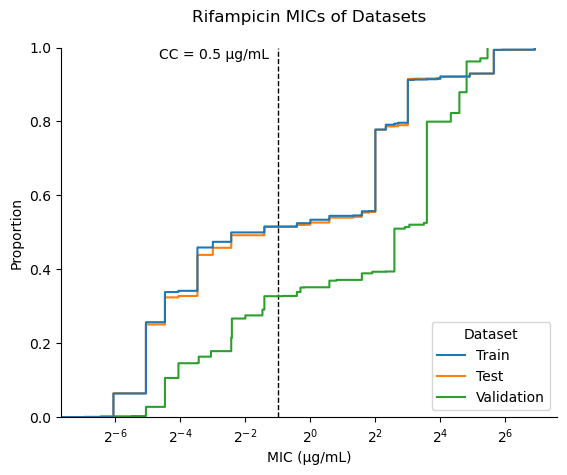

In [8]:
df_RIF = compare_distributions("RIF", "Rifampicin", label_xpos=0.04, saveName="Rifampicin/MIC_ECDF.png")

pval for Train/Test: 0.857


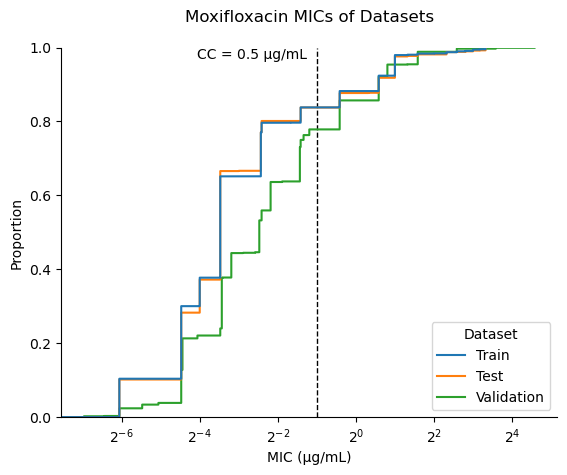

In [9]:
df_MXF = compare_distributions("MXF", "Moxifloxacin", label_xpos=0.06, saveName="Moxifloxacin/MIC_ECDF.png")

# Lineage Distributions

In [67]:
def create_stacked_percent_bar_chart(df, saveName=None):
    
    LinToColor_Dict = {"1": "#f381b2",
                       "2": "#006dbb",
                       "3": "#9f5eab",
                       "4": "#f6472b",
                       "5": "#76400e",
                       "BOV_AFRI": "white"
                      }
    
#     LinToColor_Dict = {"1": "#DF83AC",
#                    "2": "#7098CB",
#                    "3": "#815D9F",
#                    "4": "#E76956",
#                    "5": "#B67548",
#                    "6": "#6AB79E",
#                    "8": "#E4515B",
#                    "Other": "black"
#                       }
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(6, 4))

    df = df.query("~Lineage.str.contains('BOV')")
    lineage_stacked_for_plotting = df.pivot(index="Dataset", columns="Lineage", values="Count")
    lineage_stacked_for_plotting["Total"] = lineage_stacked_for_plotting.sum(axis=1)
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.fillna(0)

    # compute proportions for plotting
    for lineage in df["Lineage"].unique():
        lineage_stacked_for_plotting[lineage] = lineage_stacked_for_plotting[lineage] / lineage_stacked_for_plotting["Total"]
        
    del lineage_stacked_for_plotting["Total"]
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.reset_index().melt(id_vars="Dataset")
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(lineage_stacked_for_plotting["Dataset"].unique()))
    
    # order in increasing lineage abundance for each drug
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.sort_values(["Dataset", "value"], ascending=[True, False])
    
    # iterate through the Lineages and convert to percentages
    color_groups = lineage_stacked_for_plotting["Lineage"].unique()
    
    for i, color_group in enumerate(color_groups):        
                        
        # dataframe of proportion of each drug's samples that belong to the current lineage
        single_group = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==color_group].groupby("Dataset")["value"].sum().reset_index()

        if i > 0:
            prev_vals = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==color_groups[i-1]].groupby("Dataset")["value"].sum().reset_index()["value"].values 
            prev_vals_array += prev_vals
            
        ax.bar(single_group["Dataset"].values, 
               single_group["value"].values, 
               color=LinToColor_Dict[color_group], 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=color_group,
               width=0.6
              )
    
        # the other group is very tiny and not worth plotting
        if color_group != "Other":
            label_loc = 'center'
            annot_format = '{:.2f}'
            ax.bar_label(ax.containers[i], fmt=annot_format, label_type=label_loc, fontsize='9')
    
    plt.setp(ax.patches, linewidth=0.75)
    sns.despine()
    
    bar_scale = 0.85
    for patch in ax.patches:
        current_width = patch.get_width()
        patch.set_width(current_width * bar_scale)
    
    # Rearrange the handles and labels
    handles, labels = ax.get_legend_handles_labels()    
    handles_labels_dict = dict(zip(labels, handles))
    handles_labels_dict = collections.OrderedDict(sorted(handles_labels_dict.items()))

    # Create the legend with the rearranged handles and labels
    ax.legend(list(handles_labels_dict.values()), list(handles_labels_dict.keys()))
    sns.move_legend(ax, fontsize=8, title='Lineage', loc='upper right', #bbox_to_anchor=(1.05, 0.65),
                    ncol=len(color_groups),
                   bbox_to_anchor=(0.75, -0.15))

    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

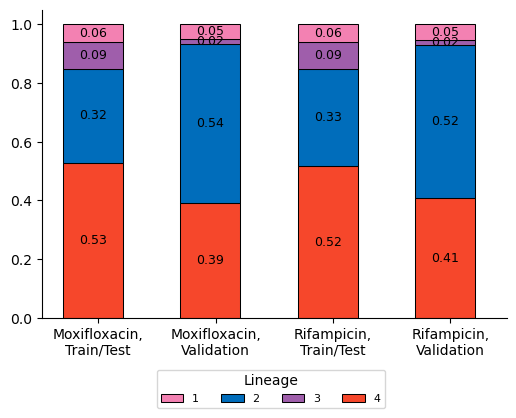

In [68]:
df_lineage_summaries = pd.DataFrame(columns=["Dataset", "Lineage", "Count"])

for df, dataset in list(zip([df_rif_train, df_rif_val, df_mxf_train, df_mxf_val], 
                            ["Rifampicin,\nTrain/Test", "Rifampicin,\nValidation", "Moxifloxacin,\nTrain/Test", "Moxifloxacin,\nValidation"])):
    
    df_summary = df["Lineage"].value_counts().reset_index()
    df_summary.columns = ["Lineage", "Count"]
    df_summary = df_summary.sort_values("Lineage", ascending=True).reset_index(drop=True)
    df_summary["Lineage"] = df_summary["Lineage"].astype(str)
    df_summary["Dataset"] = dataset
    
    df_lineage_summaries = pd.concat([df_lineage_summaries, df_summary])
    
    
create_stacked_percent_bar_chart(df_lineage_summaries)

In [3]:
def lineage_pie_chart(df, bbox=(1.4, 0.5)):

    # df_train = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
    # df_val = pd.read_csv(os.path.join(data_path, drug, "validation_data_for_model.csv"))
    
    # Pie chart, where the slices will be ordered and plotted counter-clockwise:
    df_summary = df["Lineage"].value_counts().reset_index()
    df_summary.columns = ["Lineage", "Count"]
    df_summary = df_summary.sort_values("Lineage", ascending=True).reset_index(drop=True)
    df_summary["Lineage"] = df_summary["Lineage"].astype(str)

    fig, ax = plt.subplots(figsize=(9, 6))

    LinToColor_Dict = {"1": "#f381b2",
                       "2": "#006dbb",
                       "3": "#9f5eab",
                       "4": "#f6472b",
                       # "5": "#76400e",
                       # "6": "#36ba74",
                       # "7": "#ffb000",
                       "BOV_AFRI": "black",
                      }
    
    labels = df_summary["Lineage"]
    sizes = df_summary["Count"]
    colors = [LinToColor_Dict[lineage] for lineage in df_summary["Lineage"].values]

    wedge_sizes = 100.*sizes/sizes.sum()
    patches, texts = ax.pie(sizes, colors=colors, startangle=90, radius=1.2)
    labels = ['{0}: {1:1.2f} %'.format(i,j) for i,j in zip(labels, wedge_sizes)]

    sort_legend = False
    if sort_legend:
        patches, labels, dummy =  zip(*sorted(zip(patches, labels, sizes),
                                              key=lambda x: x[2],
                                              reverse=True))


    ax.legend(patches, labels)
    sns.move_legend(ax, fontsize=12, title='', loc='center right', bbox_to_anchor=bbox)
    
    plt.tight_layout()
    plt.show()
    # sns.despine()
    #plt.savefig("Figures/lineage_pie.png", dpi=400, bbox_inches='tight')

In [4]:
# lineage_pie_chart(df_rif_train, bbox=(1.3, 0.5))

In [5]:
# lineage_pie_chart(df_rif_val)

# Distribution of MIC vs. Unique Sequences

In [8]:
df_rif = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))
df_rif_val = pd.read_csv(os.path.join(data_path, "RIF", "validation_data_for_model.csv"))

df_rif = pd.concat([df_rif[["ROLLINGDB_ID", "RIF_midpoint", "Lineage"]], df_rif_val[["ROLLINGDB_ID", "RIF_midpoint", "Lineage"]]])

In [9]:
rpoBC = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/rpoBC.fasta", "fasta")]
rpoBC = pd.DataFrame(rpoBC)
rpoBC.columns = ["ROLLINGDB_ID", "Seq"]
df_rif = rpoBC.merge(df_rif, on="ROLLINGDB_ID", how="inner")
print(df_rif.shape)

seq_num_mapping = dict(zip(df_rif.Seq.unique(), np.arange(len(df_rif.Seq.unique())).astype(str)))
df_rif["Seq_Num"] = df_rif["Seq"].map(seq_num_mapping)

(10543, 4)


In [10]:
_, seq_counts = np.unique(df_rif["Seq_Num"], return_counts=True)
len(seq_counts), np.max(seq_counts)

(1898, 1288)

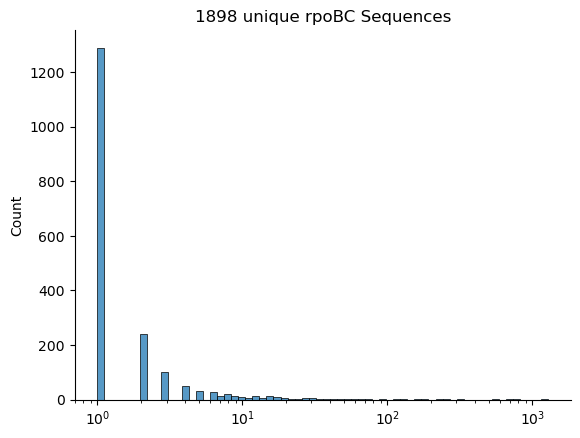

In [11]:
sns.histplot(seq_counts, log_scale=10)
sns.despine()
plt.title(f"{len(seq_counts)} unique rpoBC Sequences")
plt.show()

In [ ]:
plot_df = df_rif.groupby('Seq_Num').filter(lambda x: len(x) > 30)
print(f"{len(plot_df.Seq_Num.unique())} unique sequences")
plot_df["log2-MIC"] = np.log2(plot_df["RIF_midpoint"])

# seq_num_order = plot_df['Seq_Num'].value_counts().to_frame().index.values.astype(str)
seq_num_order = plot_df.groupby("Seq_Num").mean().sort_values("RIF_midpoint", ascending=True).index.values

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

sns.boxplot(data=plot_df,
              x="Seq_Num",
              y="log2-MIC",
              order=seq_num_order,
            fliersize=3,
              dodge=True,
              #inner="box",
              color="cornflowerblue",
              ax=ax
             )


plt.xticks([], [])
new_labels = [int(np.exp2(val)) if np.exp2(val) >= 1 else np.round(np.exp2(val), 2) for val in ax.get_yticks()]
ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels)
plt.axhline(y=np.log2(0.5), color="tomato", linewidth=1, linestyle="--")

plt.xlabel("")
plt.ylabel("MIC (µg/mL)")
sns.despine()
plt.show()

35 unique sequences
